In [56]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

In [15]:
merchant = pd.read_parquet('/Users/sapuantalaspay/vs_projects/data/data/raw/merchants_reference.parquet', engine="fastparquet")
business = pd.read_parquet('/Users/sapuantalaspay/vs_projects/data/data/raw/business_cards_MDQ.parquet', engine="fastparquet")
consumer = pd.read_parquet('/Users/sapuantalaspay/vs_projects/data/data/raw/consumer_cards_MDQ.parquet', engine="fastparquet")

In [103]:
print('business:')
print(business.shape)

print()
print('consumer')
print(consumer.shape)

print()
print('merchant')
print(merchant.shape)

business:
(2997593, 16)

consumer
(9832487, 16)

merchant
(2165, 5)


In [16]:
merchant.head()

,merchant_id,merchant_name,mcc,merchant_country,recurring_capable
0,MER_000000,Google Ads,7311,Ireland,True
1,MER_000001,Meta Ads,7311,Ireland,True
2,MER_000002,TikTok Ads,7311,Singapore,True
3,MER_000003,Yandex Direct,7311,Russia,True
4,MER_000004,LinkedIn Ads,7311,Ireland,True


In [17]:
business.head()

,transaction_date,transaction_timestamp,transaction_amount_kzt,mcc,merchant_id,channel,bank_name,country,card_number,card_tier,tokenized,is_recurring
0,1759276800000000000,2025-10-01 00:00:00,180976,7372,MER_000007,online,Kaspi,US,5228592291438845,Business,False,True
1,1759276800000000000,2025-10-01 00:00:00,153206,7372,MER_000006,online,Home Credit Bank,US,5201495142193372,Business,False,True
2,1759276800000000000,2025-10-01 00:00:00,197106,7372,MER_000007,online,Home Credit Bank,US,5201492177677288,Business,False,True
3,1759276800000000000,2025-10-01 00:01:00,189598,7372,MER_000008,online,Kaspi,US,5176513443697635,Business,False,True
4,1759276800000000000,2025-10-01 00:03:00,700571,7311,MER_000003,online,Halyk,Russia,5100611967455520,Business,False,True


In [18]:
consumer.head()

,transaction_date,transaction_timestamp,transaction_amount_kzt,mcc,merchant_id,channel,bank_name,country,card_number,card_tier,tokenized,is_recurring
0,1759276800000000000,2025-10-01 00:04:00,4788,4814,MER_000064,online,Alatau City Bank,Kazakhstan,5263907968824596,Standard,False,True
1,1759276800000000000,2025-10-01 00:10:00,5240,4814,MER_000063,online,Bank RBK,Kazakhstan,5119023663984986,Standard,False,True
2,1759276800000000000,2025-10-01 00:12:00,4576,4814,MER_000066,online,Kaspi,Kazakhstan,5228590878155154,Standard,False,True
3,1759276800000000000,2025-10-01 00:37:00,6078,4814,MER_000063,online,Home Credit Bank,Kazakhstan,5338472125333693,Standard,False,True
4,1759276800000000000,2025-10-01 00:37:00,6042,4814,MER_000065,online,Kaspi,Kazakhstan,5531514712394557,Affluent,False,True


In [39]:
business.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2997593 entries, 0 to 2997592
Data columns (total 12 columns):
 #   Column                  Dtype        
---  ------                  -----        
 0   transaction_date        object       
 1   transaction_timestamp   datetime64[s]
 2   transaction_amount_kzt  int64        
 3   mcc                     object       
 4   merchant_id             object       
 5   channel                 object       
 6   bank_name               object       
 7   country                 object       
 8   card_number             object       
 9   card_tier               object       
 10  tokenized               bool         
 11  is_recurring            bool         
dtypes: bool(2), datetime64[s](1), int64(1), object(8)
memory usage: 234.4+ MB


In [40]:
consumer.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9832487 entries, 0 to 9832486
Data columns (total 12 columns):
 #   Column                  Dtype         
---  ------                  -----         
 0   transaction_date        object        
 1   transaction_timestamp   datetime64[ms]
 2   transaction_amount_kzt  int64         
 3   mcc                     object        
 4   merchant_id             object        
 5   channel                 object        
 6   bank_name               object        
 7   country                 object        
 8   card_number             object        
 9   card_tier               object        
 10  tokenized               bool          
 11  is_recurring            bool          
dtypes: bool(2), datetime64[ms](1), int64(1), object(8)
memory usage: 768.9+ MB


In [41]:
merchant.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2165 entries, 0 to 2164
Data columns (total 5 columns):
 #   Column             Non-Null Count  Dtype 
---  ------             --------------  ----- 
 0   merchant_id        2165 non-null   object
 1   merchant_name      2165 non-null   object
 2   mcc                2165 non-null   object
 3   merchant_country   2165 non-null   object
 4   recurring_capable  2165 non-null   bool  
dtypes: bool(1), object(4)
memory usage: 69.9+ KB


## Провека на дубликаты

In [192]:
print(business.duplicated().sum())
print(consumer.duplicated().sum())
print(merchant.duplicated().sum())

0
0
0


## Проверка на пропущенные значения

In [ ]:
print(consumer.isnull().sum())

transaction_date          0
transaction_timestamp     0
transaction_amount_kzt    0
mcc                       0
merchant_id               0
channel                   0
bank_name                 0
country                   0
card_number               0
card_tier                 0
tokenized                 0
is_recurring              0
dtype: int64 



In [54]:
print(business.isnull().sum())

transaction_date          0
transaction_timestamp     0
transaction_amount_kzt    0
mcc                       0
merchant_id               0
channel                   0
bank_name                 0
country                   0
card_number               0
card_tier                 0
tokenized                 0
is_recurring              0
dtype: int64


In [55]:
print(merchant.isnull().sum())

merchant_id          0
merchant_name        0
mcc                  0
merchant_country     0
recurring_capable    0
dtype: int64


In [194]:
business["transaction_date"].min(), business["transaction_date"].max()
consumer["transaction_date"].min(), consumer["transaction_date"].max()

(1759276800000000000, 1774915200000000000)

## Проверка бизнес смысла merchant_id и mcc 

In [31]:
multi_mcc_merchants = (
    business.groupby('merchant_id')
    .agg(
        unique_mcc=('mcc', 'nunique'),
        tx_count=('mcc', 'size')
    )
    .query('unique_mcc > 1')
    .sort_values(['unique_mcc', 'tx_count'], ascending=False)
)

multi_mcc_merchants.head(20)

,unique_mcc,tx_count
merchant_id,,
MER_000000,2,63450


In [32]:
business[business['merchant_id'] == 'MER_000000']['mcc'].value_counts(normalize=False)

mcc
7311    45749
7012    17701
Name: count, dtype: int64

In [33]:
merchant[merchant['merchant_id'] == 'MER_000000']

,merchant_id,merchant_name,mcc,merchant_country,recurring_capable
0,MER_000000,Google Ads,7311,Ireland,True


### MER_000000 имеет 2 mcc в business
дальше проверим в consumer

In [35]:
consumer_multi_mcc_merchants = (
    consumer.groupby('merchant_id')
    .agg(
        unique_mcc=('mcc', 'nunique'),
        tx_count=('mcc', 'size')
    )
    .query('unique_mcc > 1')
    .sort_values(['unique_mcc', 'tx_count'], ascending=False)
)

consumer_multi_mcc_merchants.head(20)

,unique_mcc,tx_count
merchant_id,,
MER_000000,2,87019


In [37]:
consumer[consumer['merchant_id'] == 'MER_000000']['mcc'].value_counts()

mcc
7311    43869
7012    43150
Name: count, dtype: int64

In [43]:
print("Share of MER_000000 in business:")

print(business['merchant_id'].eq('MER_000000').mean() * 100)

print()
print("Share of MER_000000 in consumer:")

print(consumer['merchant_id'].eq('MER_000000').mean() * 100)

Share of MER_000000 in business:
2.116698297600775

Share of MER_000000 in consumer:
0.8850151543551494


In [48]:
for name, df in [('business', business), ('consumer', consumer)]:
    total_rows = len(df)
    unknown_rows = df['merchant_id'].eq('MER_000000').sum()
    share = unknown_rows / total_rows * 100

    print(f'{name}:')
    print(f'total rows: {total_rows:,}')
    print(f'MER_000000 rows: {unknown_rows:,}')
    print(f'share: {share:.4f}%\n')


business:
total rows: 2,997,593
MER_000000 rows: 63,450
share: 2.1167%

consumer:
total rows: 9,832,487
MER_000000 rows: 87,019
share: 0.8850%



## salam

In [ ]:
num_cols = consumer.select_dtypes(include=["number"]).columns.tolist()
cat_cols = consumer.select_dtypes(include=["object", "category", "bool"]).columns.tolist()

In [60]:
consumer[cat_cols].describe()

,transaction_date,mcc,merchant_id,channel,bank_name,country,card_number,card_tier,tokenized,is_recurring
count,9832487,9832487,9832487,9832487,9832487,9832487,9832487,9832487,9832487,9832487
unique,182,500,2060,2,11,18,80000,3,2,2
top,1765065600000000000,4814,MER_000000,POS,Kaspi,Kazakhstan,5119024906446569,Standard,False,False
freq,79070,451480,87019,5259386,3147579,7260651,354,7328850,6034660,9565241


In [61]:
business[cat_cols].describe()

,transaction_date,mcc,merchant_id,channel,bank_name,country,card_number,card_tier,tokenized,is_recurring
count,2997593,2997593,2997593,2997593,2997593,2997593,2997593,2997593,2997593,2997593
unique,182,104,481,2,11,18,25000,1,2,2
top,1771891200000000000,7311,MER_000000,online,Kaspi,Kazakhstan,5338479101115044,Business,True,False
freq,36882,271527,63450,2537848,947153,2118885,242,2997593,1798580,2597573


In [85]:
pd.options.display.float_format = "{:,.0f}".format
print('For Consumer:')
display(consumer[num_cols].describe())
print('For Business')
display(business[num_cols].describe())

For Consumer:


,transaction_amount_kzt
count,"9,832,487"
mean,"54,045"
std,"169,655"
min,15
25%,"4,172"
50%,"11,892"
75%,"39,665"
max,"31,971,032"


For Business


,transaction_amount_kzt
count,"2,997,593"
mean,"156,535"
std,"252,868"
min,67
25%,"22,835"
50%,"77,224"
75%,"196,081"
max,"40,799,297"


In [105]:
business['transaction_amount_kzt'].value_counts().head()

transaction_amount_kzt
1175    108
1539    105
1502    105
1425    105
1354    105
Name: count, dtype: int64

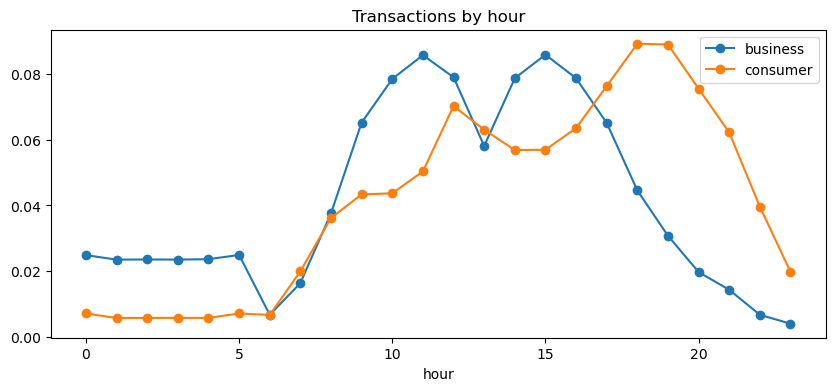

In [168]:
for df in [business, consumer]:
    df["ts"] = pd.to_datetime(df["transaction_timestamp"])
    df["hour"] = df["ts"].dt.hour
    df["dow"] = df["ts"].dt.dayofweek
    df["month"] = df["ts"].dt.to_period("M")

hourly = pd.DataFrame({
    "business": business["hour"].value_counts(normalize=True).sort_index(),
    "consumer": consumer["hour"].value_counts(normalize=True).sort_index(),
})

hourly.plot(figsize=(10, 4), marker="o")
plt.title("Transactions by hour")
plt.show()

In [110]:
amount_check = pd.DataFrame({
    "business": business["transaction_amount_kzt"].describe(),
    "consumer": consumer["transaction_amount_kzt"].describe()
})

amount_check

,business,consumer
count,"2,997,593","9,832,487"
mean,"156,535","54,045"
std,"252,868","169,655"
min,67,15
25%,"22,835","4,172"
50%,"77,224","11,892"
75%,"196,081","39,665"
max,"40,799,297","31,971,032"


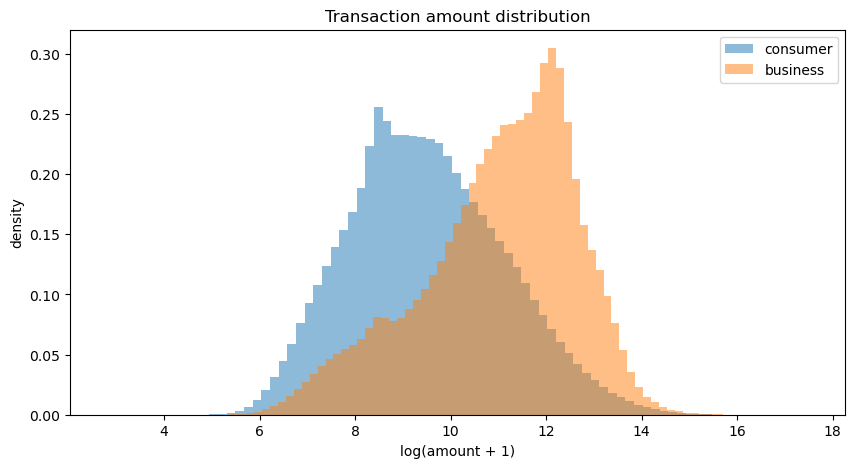

In [ ]:
plt.figure(figsize=(10, 5))

plt.hist(
    np.log1p(consumer["transaction_amount_kzt"]),
    bins=80,
    alpha=0.5,
    label="consumer",
    density=True
)

plt.hist(
    np.log1p(business["transaction_amount_kzt"]),
    bins=80,
    alpha=0.5,
    label="business",
    density=True
)

plt.legend()
plt.title("Transaction amount distribution")
plt.xlabel("log(amount + 1)")
plt.ylabel("density")
plt.show()

## Join merchant with consumer and business

In [112]:
business_m = business.merge(
    merchant,
    on="merchant_id",
    how="left",
    validate="many_to_one"
)

consumer_m = consumer.merge(
    merchant,
    on="merchant_id",
    how="left",
    validate="many_to_one"
)

In [114]:
business_m.head()

,transaction_date,transaction_timestamp,transaction_amount_kzt,mcc_x,merchant_id,channel,bank_name,country,card_number,card_tier,tokenized,is_recurring,ts,hour,dow,month,merchant_name,mcc_y,merchant_country,recurring_capable
0,1759276800000000000,2025-10-01 00:00:00,180976,7372,MER_000007,online,Kaspi,US,5228592291438845,Business,False,True,2025-10-01 00:00:00,0,2,2025-10,Microsoft Azure,7372,US,True
1,1759276800000000000,2025-10-01 00:00:00,153206,7372,MER_000006,online,Home Credit Bank,US,5201495142193372,Business,False,True,2025-10-01 00:00:00,0,2,2025-10,Amazon Web Services,7372,US,True
2,1759276800000000000,2025-10-01 00:00:00,197106,7372,MER_000007,online,Home Credit Bank,US,5201492177677288,Business,False,True,2025-10-01 00:00:00,0,2,2025-10,Microsoft Azure,7372,US,True
3,1759276800000000000,2025-10-01 00:01:00,189598,7372,MER_000008,online,Kaspi,US,5176513443697635,Business,False,True,2025-10-01 00:01:00,0,2,2025-10,Google Cloud,7372,US,True
4,1759276800000000000,2025-10-01 00:03:00,700571,7311,MER_000003,online,Halyk,Russia,5100611967455520,Business,False,True,2025-10-01 00:03:00,0,2,2025-10,Yandex Direct,7311,Russia,True


In [115]:
print("business missing merchant info:")
display(business_m[["merchant_name", "merchant_country", "recurring_capable"]].isna().sum())

print("consumer missing merchant info:")
display(consumer_m[["merchant_name", "merchant_country", "recurring_capable"]].isna().sum())

business missing merchant info:


merchant_name        0
merchant_country     0
recurring_capable    0
dtype: int64

consumer missing merchant info:


merchant_name        0
merchant_country     0
recurring_capable    0
dtype: int64

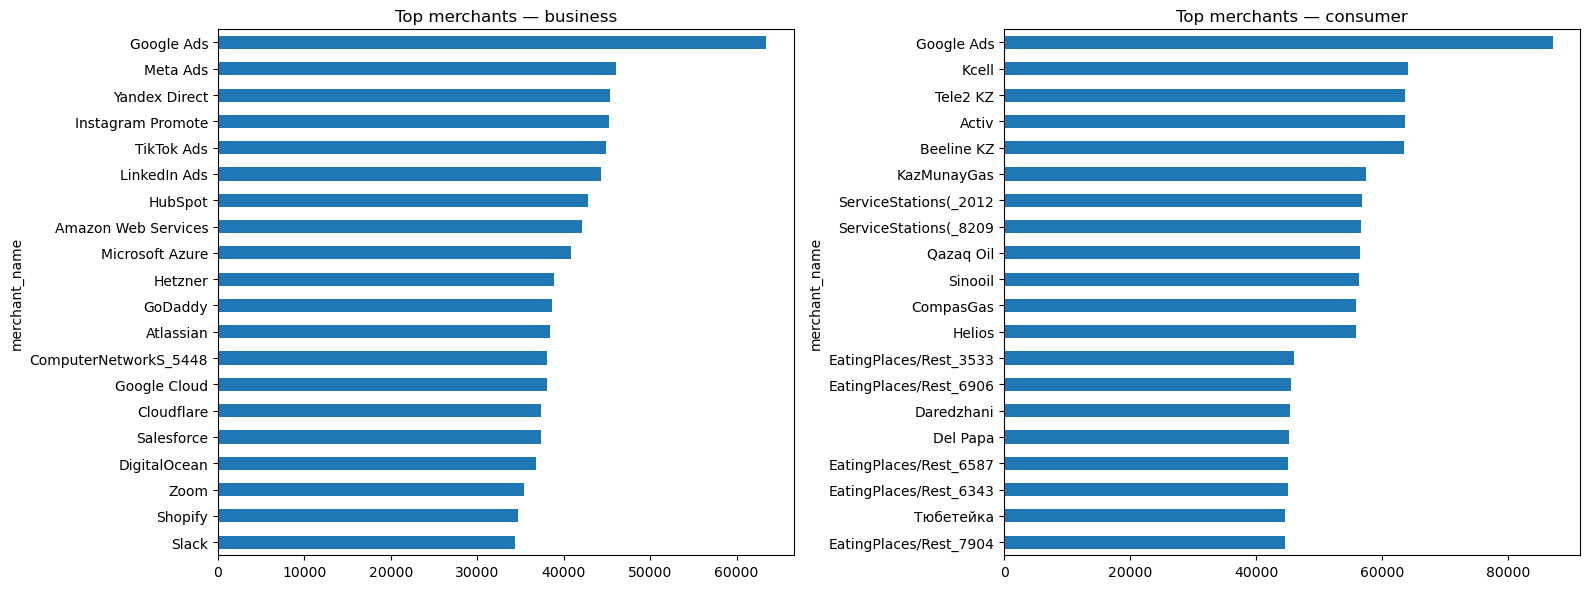

In [118]:
top_n = 20

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

business_m["merchant_name"].value_counts().head(top_n).sort_values().plot(
    kind="barh",
    ax=axes[0],
    title="Top merchants — business"
)

consumer_m["merchant_name"].value_counts().head(top_n).sort_values().plot(
    kind="barh",
    ax=axes[1],
    title="Top merchants — consumer"
)

plt.tight_layout()
plt.show()

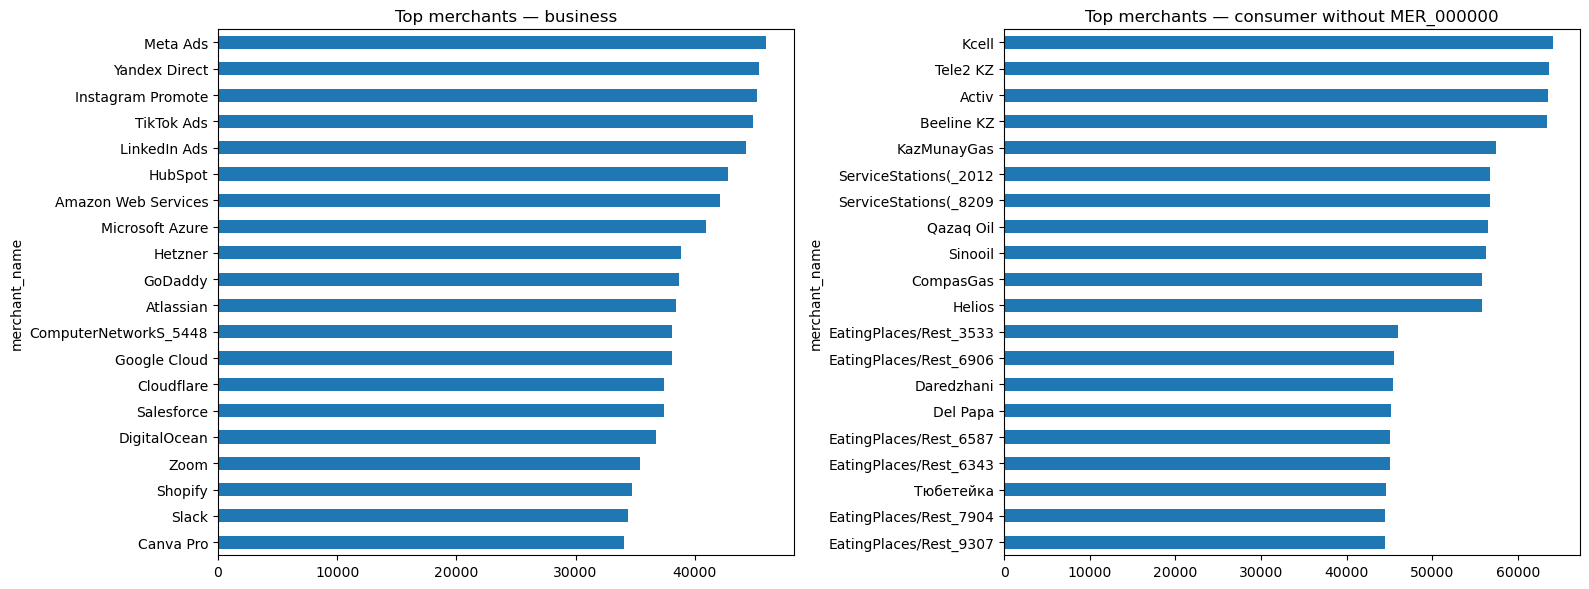

In [120]:
top_n = 20

consumer_plot = consumer_m[consumer_m["merchant_id"] != "MER_000000"]
business_plot = business_m[business_m["merchant_id"] != "MER_000000"]

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

business_plot["merchant_name"].value_counts().head(top_n).sort_values().plot(
    kind="barh",
    ax=axes[0],
    title="Top merchants — business"
)

consumer_plot["merchant_name"].value_counts().head(top_n).sort_values().plot(
    kind="barh",
    ax=axes[1],
    title="Top merchants — consumer without MER_000000"
)

plt.tight_layout()
plt.show()

In [124]:
business_plot = business_m[
    ~(
        (business_m["merchant_id"] == "MER_000000") &
        (business_m["mcc_y"].astype(str) != "7012")
    )
].copy()

consumer_plot = consumer_m[
    ~(
        (consumer_m["merchant_id"] == "MER_000000") &
        (consumer_m["mcc_y"].astype(str) != "7012")
    )
].copy()

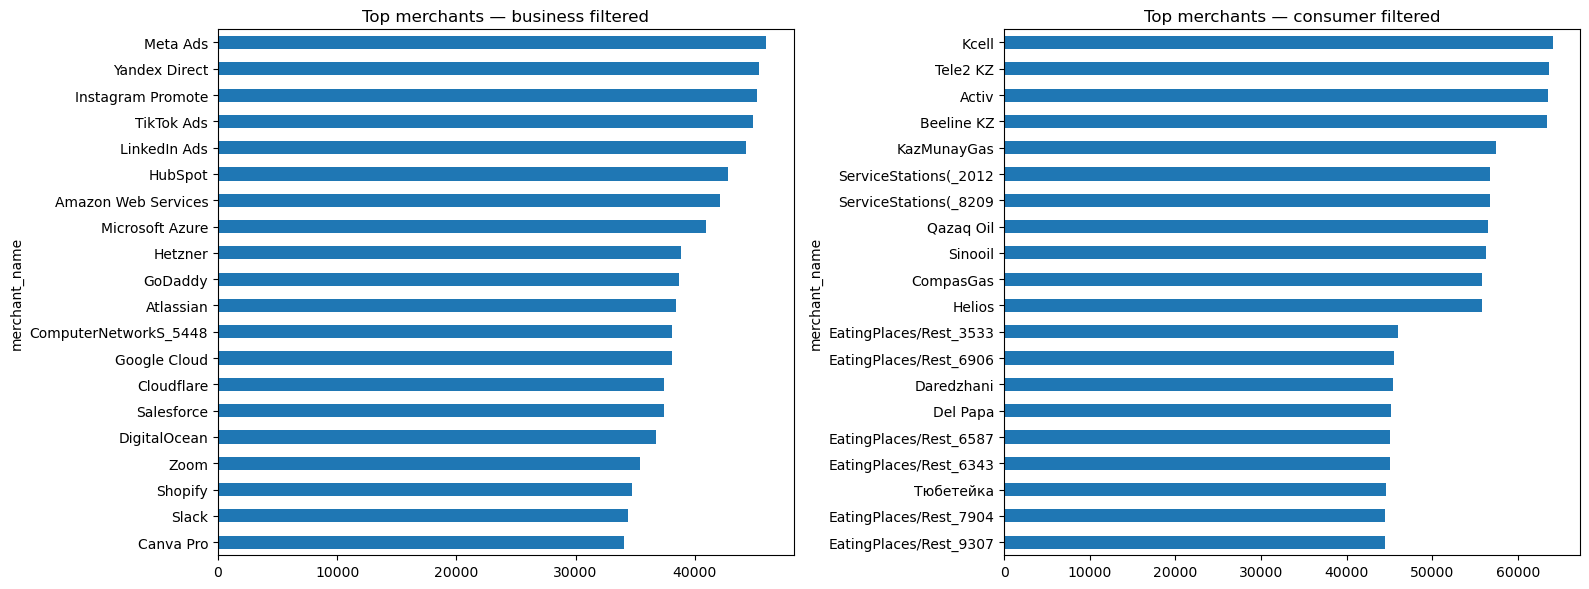

In [125]:
top_n = 20

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

business_plot["merchant_name"].value_counts().head(top_n).sort_values().plot(
    kind="barh",
    ax=axes[0],
    title="Top merchants — business filtered"
)

consumer_plot["merchant_name"].value_counts().head(top_n).sort_values().plot(
    kind="barh",
    ax=axes[1],
    title="Top merchants — consumer filtered"
)

plt.tight_layout()
plt.show()

In [126]:
biz_card_txn = business_m.groupby("card_number").size()
con_card_txn = consumer_m.groupby("card_number").size()

pd.DataFrame({
    "business": biz_card_txn.describe(),
    "consumer": con_card_txn.describe()
})

,business,consumer
count,"25,000","80,000"
mean,120,123
std,43,48
min,26,17
25%,84,85
50%,119,120
75%,155,156
max,242,354


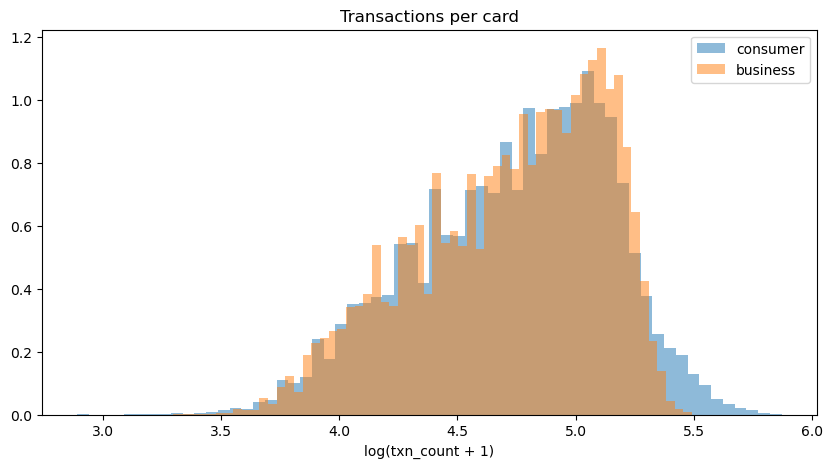

In [127]:
plt.figure(figsize=(10, 5))

plt.hist(np.log1p(con_card_txn), bins=60, alpha=0.5, label="consumer", density=True)
plt.hist(np.log1p(biz_card_txn), bins=60, alpha=0.5, label="business", density=True)

plt.title("Transactions per card")
plt.xlabel("log(txn_count + 1)")
plt.legend()
plt.show()

#### Этот график показывает общую сумму расходов на одну карту.

#### Количество транзакций на карту само по себе не является сильным признаком для отделения business от consumer по графику и по статистике выше

In [129]:
biz_card_total = business_m.groupby("card_number")["transaction_amount_kzt"].sum()
con_card_total = consumer_m.groupby("card_number")["transaction_amount_kzt"].sum()

pd.DataFrame({
    "business": biz_card_total.describe(),
    "consumer": con_card_total.describe()
})

,business,consumer
count,"25,000","80,000"
mean,"18,769,162","6,642,512"
std,"6,897,553","8,606,655"
min,"2,615,035","345,287"
25%,"13,637,013","1,966,989"
50%,"17,714,892","2,976,294"
75%,"22,885,893","6,259,916"
max,"64,357,034","170,159,026"


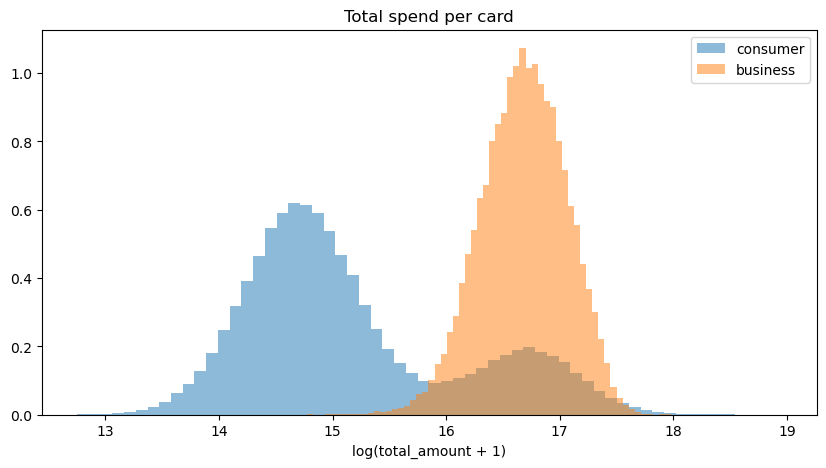

In [130]:
plt.figure(figsize=(10, 5))

plt.hist(np.log1p(con_card_total), bins=60, alpha=0.5, label="consumer", density=True)
plt.hist(np.log1p(biz_card_total), bins=60, alpha=0.5, label="business", density=True)

plt.title("Total spend per card")
plt.xlabel("log(total_amount + 1)")
plt.legend()
plt.show()

#### График показывает общий оборот по каждой карте за весь период.

#### Бизнес-карты не обязательно совершают больше транзакций, чем обычные карты, но сумма расходов по ним значительно выше. Значит, ключевое отличие business-сегмента — не частота покупок, а размер платежей и общий оборот по карте.

In [132]:
biz_unique_merchants = business_m.groupby("card_number")["merchant_id"].nunique()
con_unique_merchants = consumer_m.groupby("card_number")["merchant_id"].nunique()

pd.DataFrame({
    "business": biz_unique_merchants.describe(),
    "consumer": con_unique_merchants.describe()
})

,business,consumer
count,"25,000","80,000"
mean,17,37
std,7,14
min,4,2
25%,12,28
50%,16,37
75%,21,47
max,49,95


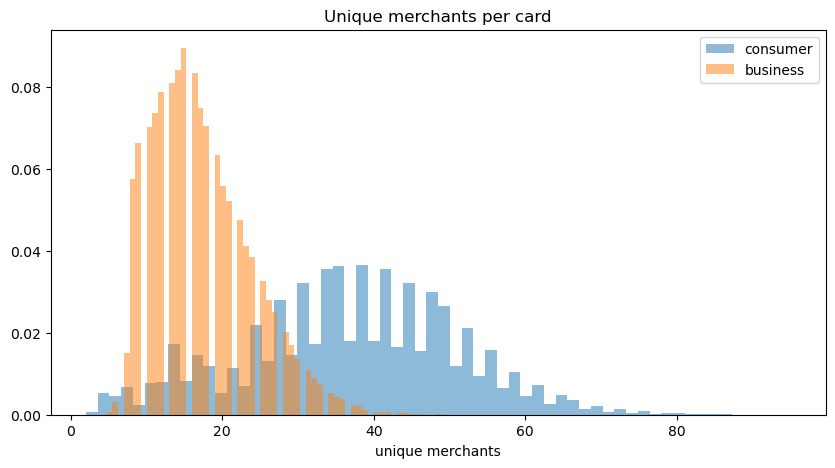

In [133]:
plt.figure(figsize=(10, 5))

plt.hist(con_unique_merchants, bins=60, alpha=0.5, label="consumer", density=True)
plt.hist(biz_unique_merchants, bins=60, alpha=0.5, label="business", density=True)

plt.title("Unique merchants per card")
plt.xlabel("unique merchants")
plt.legend()
plt.show()

#### consumer-карты ходят к гораздо большему числу разных мерчантов, а business-карты более концентрированы на меньшем количестве мерчантов

In [134]:
biz_unique_mcc = business_m.groupby("card_number")["mcc_x"].nunique()
con_unique_mcc = consumer_m.groupby("card_number")["mcc_x"].nunique()

pd.DataFrame({
    "business": biz_unique_mcc.describe(),
    "consumer": con_unique_mcc.describe()
})

,business,consumer
count,"25,000","80,000"
mean,15,32
std,4,11
min,4,2
25%,12,24
50%,15,32
75%,18,40
max,28,64


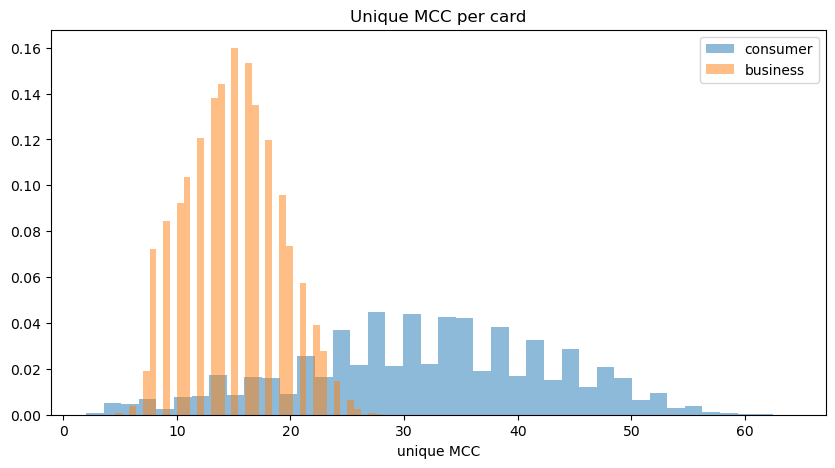

In [135]:
plt.figure(figsize=(10, 5))

plt.hist(con_unique_mcc, bins=40, alpha=0.5, label="consumer", density=True)
plt.hist(biz_unique_mcc, bins=40, alpha=0.5, label="business", density=True)

plt.title("Unique MCC per card")
plt.xlabel("unique MCC")
plt.legend()
plt.show()

#### consumer-карты используют намного больше разных MCC-категорий, business-карты более сфокусированы на некотором наборе категорий

In [143]:
biz_recurring_capable_ratio = business_m.groupby("card_number")["recurring_capable"].mean()
con_recurring_capable_ratio = consumer_m.groupby("card_number")["recurring_capable"].mean()

result = pd.DataFrame({
    "business": biz_recurring_capable_ratio.describe(),
    "consumer": con_recurring_capable_ratio.describe()
})

print(result.to_string(float_format=lambda x: f"{x:.6f}"))

          business     consumer
count 25000.000000 80000.000000
mean      0.336262     0.074016
std       0.172652     0.144665
min       0.000000     0.000000
25%       0.204545     0.000000
50%       0.294118     0.032110
75%       0.450980     0.081250
max       0.914286     1.000000


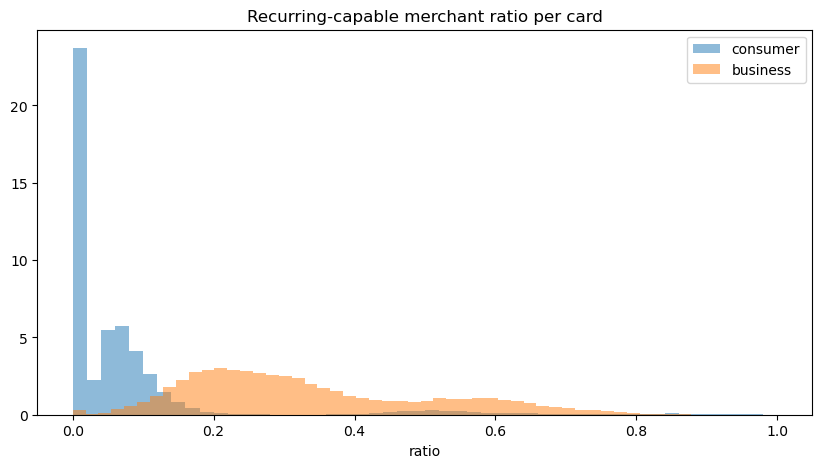

In [137]:
plt.figure(figsize=(10, 5))

plt.hist(con_recurring_capable_ratio, bins=50, alpha=0.5, label="consumer", density=True)
plt.hist(biz_recurring_capable_ratio, bins=50, alpha=0.5, label="business", density=True)

plt.title("Recurring-capable merchant ratio per card")
plt.xlabel("ratio")
plt.legend()
plt.show()

#### business-карты намного чаще используют recurring-capable merchants(33.6% на 7.4%)

In [154]:
pd.options.display.float_format = "{:,.4f}".format

In [169]:
for df in [business_m, consumer_m]:
    df["ts"] = pd.to_datetime(df["transaction_timestamp"])
    df["hour"] = df["ts"].dt.hour
    df["dow"] = df["ts"].dt.dayofweek

    df["is_weekend"] = df["dow"] >= 5

    df["weekday_business_hours"] = (
        (df["dow"] < 5) &
        (df["hour"].between(9, 18))
    )

    df["weekday_non_business_hours"] = (
        (df["dow"] < 5) &
        (~df["hour"].between(9, 18))
    )

In [ ]:
# Transaction-level сравнение:
time_cols = [
    "weekday_business_hours",
    "weekday_non_business_hours",
    "is_weekend"
]

time_compare = pd.DataFrame({
    "business": business_m[time_cols].mean(),
    "consumer": consumer_m[time_cols].mean(),
})

time_compare

,business,consumer
weekday_business_hours,0.6474,0.3997
weekday_non_business_hours,0.2281,0.2523
is_weekend,0.1245,0.3480


In [ ]:
# Card-level сравнение:
biz_card_time = business_m.groupby("card_number")[time_cols].mean()
con_card_time = consumer_m.groupby("card_number")[time_cols].mean()

pd.DataFrame({
    "business_median": biz_card_time.median(),
    "consumer_median": con_card_time.median(),
    "business_mean": biz_card_time.mean(),
    "consumer_mean": con_card_time.mean(),
})

,business_median,consumer_median,business_mean,consumer_mean
weekday_business_hours,0.6429,0.3947,0.6304,0.4013
weekday_non_business_hours,0.2316,0.2525,0.2405,0.2535
is_weekend,0.1241,0.3502,0.1291,0.3452


#### business = больше активности в рабочие часы, меньше на выходных
#### consumer = больше активности вне строгого рабочего графика, особенно на выходных

In [157]:
channel_compare = pd.concat([
    business_m["channel"].value_counts(normalize=True).rename("business"),
    consumer_m["channel"].value_counts(normalize=True).rename("consumer")
], axis=1).fillna(0)

channel_compare

,business,consumer
channel,,
online,0.8466,0.4651
POS,0.1534,0.5349


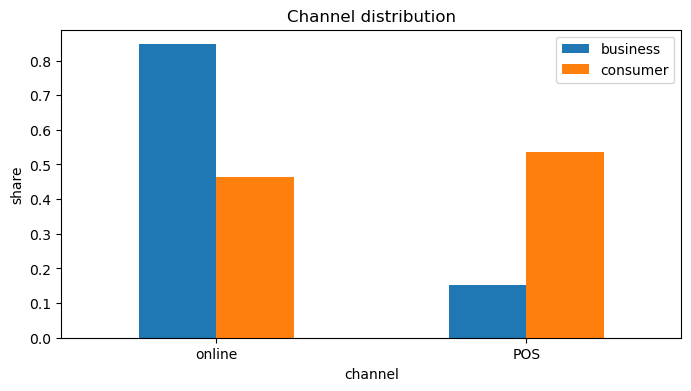

In [158]:
channel_compare.plot(kind="bar", figsize=(8, 4))
plt.title("Channel distribution")
plt.ylabel("share")
plt.xticks(rotation=0)
plt.show()

#### business-карты намного чаще используются online
#### consumer-карты чаще используются через POS

In [159]:
recurring_compare = pd.DataFrame({
    "business": [
        business_m["is_recurring"].mean(),
        business_m["recurring_capable"].mean(),
    ],
    "consumer": [
        consumer_m["is_recurring"].mean(),
        consumer_m["recurring_capable"].mean(),
    ]
}, index=["is_recurring_ratio", "recurring_capable_merchant_ratio"])

recurring_compare

,business,consumer
is_recurring_ratio,0.1334,0.0272
recurring_capable_merchant_ratio,0.3213,0.0687


#### Business-карты значительно чаще связаны с регулярными платежами. Около 13.3% business-транзакций реально являются recurring, тогда как у consumer таких только 2.7%. Кроме того, 32.1% business-транзакций проходят у мерчантов, которые способны принимать recurring-платежи, против 6.9% у consumer. Это говорит о том, что business-карты чаще используются для регулярных операционных расходов: подписок, сервисов, рекламы, цифровых инструментов и других повторяющихся бизнес-платежей.

In [160]:
thresholds = [10_000, 50_000, 100_000, 500_000]

rows = []

for t in thresholds:
    rows.append({
        "threshold": t,
        "business_share": (business_m["transaction_amount_kzt"] >= t).mean(),
        "consumer_share": (consumer_m["transaction_amount_kzt"] >= t).mean(),
    })

large_txn_compare = pd.DataFrame(rows)
large_txn_compare

,threshold,business_share,consumer_share
0,10000,0.8470,0.5401
1,50000,0.6022,0.2122
2,100000,0.4370,0.1177
3,500000,0.0640,0.0170


#### business-карты значительно чаще совершают крупные транзакции

In [179]:
mcc_ref = pd.read_csv("/Users/sapuantalaspay/vs_projects/data/data/raw/mcc.csv")

mcc_ref.head()

,mcc,mcc_name,page
0,742,Veterinary Services,2
1,763,Agricultural Cooperatives,2
2,780,Horticultural and Landscaping Services,2
3,1520,"General Contractors, residential and commercial",2
4,1711,"Air Conditioning, Heating, and Plumbing Contra...",2


#### взяли все mcc из mastercard Quick Reference Booklet(https://www.mastercard.com/content/dam/public/mastercardcom/na/global-site/documents/mastercard-quick-reference-booklet-merchant.pdf)

In [180]:
for name, df in [("business", business_m), ("consumer", consumer_m)]:
    print(name)

    display(
        df[df["merchant_id"] == "MER_000000"]
        .groupby(["merchant_id", "merchant_name", "mcc_x", "mcc_y"])
        .size()
        .sort_values(ascending=False)
        .to_frame("rows")
    )

business


rows
merchant_id merchant_name mcc_x mcc_y       
MER_000000  Google Ads    7311  7311   45749
                          7012  7311   17701

consumer


rows
merchant_id merchant_name mcc_x mcc_y       
MER_000000  Google Ads    7311  7311   43869
                          7012  7311   43150

In [181]:
for df in [business_m, consumer_m]:
    df["mcc_final"] = df["mcc_x"].astype(str)

In [183]:
mcc_ref["mcc"] = mcc_ref["mcc"].astype(str)

for df in [business_m, consumer_m]:
    df["mcc_final"] = df["mcc_final"].astype(str)

In [186]:
biz_mcc = business_m["mcc_final"].value_counts(normalize=True)
con_mcc = consumer_m["mcc_final"].value_counts(normalize=True)

mcc_compare = pd.concat([
    biz_mcc.rename("business_share"),
    con_mcc.rename("consumer_share")
], axis=1).fillna(0)

mcc_compare["diff_pp"] = (
    mcc_compare["business_share"] - mcc_compare["consumer_share"]
) * 100

mcc_compare["ratio_biz_to_consumer"] = (
    mcc_compare["business_share"] /
    mcc_compare["consumer_share"].replace(0, np.nan)
)

# вот эта часть фиксит проблему
mcc_compare = mcc_compare.reset_index()
mcc_compare = mcc_compare.rename(columns={mcc_compare.columns[0]: "mcc"})

mcc_compare["mcc"] = mcc_compare["mcc"].astype(str)
mcc_ref["mcc"] = mcc_ref["mcc"].astype(str)

mcc_compare = mcc_compare.merge(
    mcc_ref[["mcc", "mcc_name"]],
    on="mcc",
    how="left"
)

In [187]:
mcc_view = mcc_compare[[
    "mcc",
    "mcc_name",
    "business_share",
    "consumer_share",
    "diff_pp",
    "ratio_biz_to_consumer"
]]

mcc_view.sort_values("diff_pp", ascending=False).head(20).style.format({
    "business_share": "{:.2%}",
    "consumer_share": "{:.2%}",
    "diff_pp": "{:.2f}",
    "ratio_biz_to_consumer": "{:.2f}x",
})

,mcc,mcc_name,business_share,consumer_share,diff_pp,ratio_biz_to_consumer
1,7372,"Computer Programming, Data Processing, and Integrated Systems Design Services",8.00%,0.47%,7.53,17.00x
0,7311,Advertising Services,9.06%,2.60%,6.45,3.48x
2,5968,Direct Marketing: Continuity/Subscription Merchants,6.86%,0.48%,6.38,14.34x
3,4816,Computer Network/Information Services,6.33%,0.28%,6.05,22.24x
4,7399,Business Services: not elsewhere classified,3.64%,0.06%,3.58,60.82x
7,5045,"Computers, Computer Peripheral Equipment, Software",3.14%,0.06%,3.08,55.38x
8,7392,"Consulting, Management, and Public Relations Services",3.13%,0.13%,3.00,24.68x
10,4214,"Motor Freight Carriers, Trucking: Local/Long Distance, Moving and Storage",2.78%,0.13%,2.65,20.80x
12,5046,Commercial Equipment: not elsewhere classified,2.55%,0.13%,2.41,19.12x
11,4215,"Courier Services: Air and Ground, Freight Forwarders",2.62%,0.21%,2.41,12.65x


#### Business-карты чаще тратят деньги на рабочие и сервисные расходы. В топе у них IT/софт, реклама, подписки, бизнес-услуги, логистика, офисные товары, бухгалтерия, юридические услуги и телеком. Например, категория MCC 7372 встречается у business-карт в 8.0% транзакций, а у consumer только в 0.47%. То есть у business она встречается примерно в 17 раз чаще.

In [189]:
tier_compare = pd.concat([
    consumer_m["card_tier"].value_counts(normalize=True).rename("consumer")
], axis=1).fillna(0)

tier_compare

,consumer
card_tier,
Standard,0.7454
Affluent,0.2097
Premium,0.0449
